In [16]:
import sys
import os

# Add project root to path
sys.path.append(os.path.abspath(".."))

In [17]:
import numpy as np
import imageio.v3 as iio
import matplotlib.pyplot as plt

from core.data import CompressionMetrics
from core.utils import convert_to_gray_scale, round_sig
from core.image import compress_image, reconstruct_image

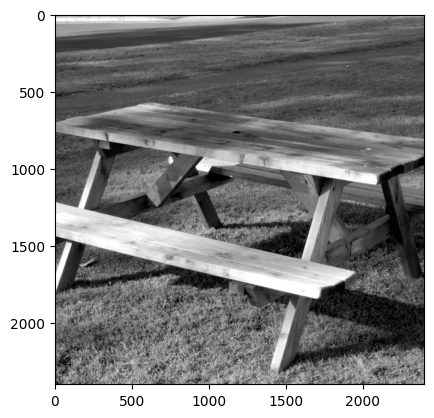

In [26]:
# import the image, and convert to gray scale
img_rgb = iio.imread("../sources/garden_table.png").astype(np.float32)
img_gray = convert_to_gray_scale(img_rgb)
plt.imshow(img_gray, cmap="gray")
plt.show()

In [19]:
# Hyperparameters
block_size = 20
poly_degree = 15
lp_degree = 2.0
cutoff = None

In [20]:
c, X_design, rescale = compress_image(
    img_gray,
    poly_degree=poly_degree,
    block_size=block_size,
    lp_degree=lp_degree,
    p_inv=True,
)

[Parallel(n_jobs=-1)]: Using backend LokyBackend with 8 concurrent workers.
[Parallel(n_jobs=-1)]: Done   2 tasks      | elapsed:    1.8s
[Parallel(n_jobs=-1)]: Done  64 tasks      | elapsed:    2.0s
[Parallel(n_jobs=-1)]: Done 2320 tasks      | elapsed:    2.1s
[Parallel(n_jobs=-1)]: Done 14400 out of 14400 | elapsed:    2.4s finished


In [27]:
# round_sig forces np.float16 — achieve smaller file size
c = round_sig(c)
img_gray_rec = reconstruct_image(c, X_design, rescale)

In [22]:
# Saving coefficients
np.save("../results/image/garden_table/coefficients/coefficients__bs=%s__cutoff=%s__lp=%s__poly_deg=%s__dtype=%s.npy" %
(block_size, cutoff, lp_degree, poly_degree, c.dtype), c, allow_pickle=False)

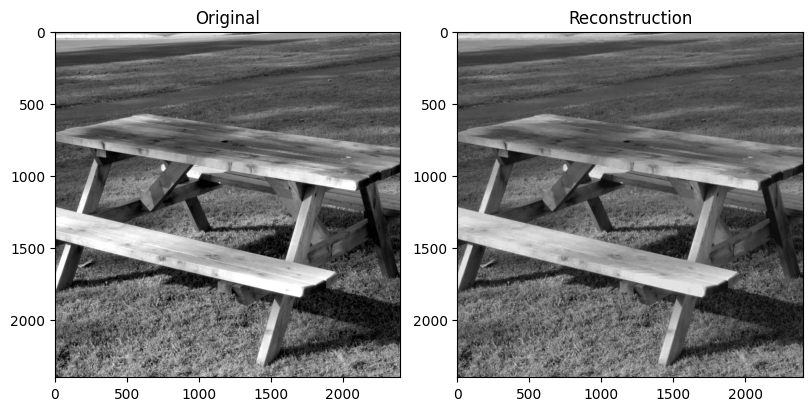

In [23]:
fig, ax = plt.subplots(1, 2, figsize=(12, 4), layout="compressed")
ax[0].imshow(img_gray, cmap="gray")
ax[0].set_title("Original")

ax[1].imshow(img_gray_rec, cmap="gray")
ax[1].set_title("Reconstruction")

fig.savefig("../results/image/garden_table_example.png")

plt.show()

In [24]:
metrics = CompressionMetrics(img_gray, img_gray_rec, c)

In [25]:
import pandas as pd
metrics_dict = {
    "Metric": ["Nonzero Coefficients (%)", "MSE", "PSNR (dB)", "Compression Ratio (%)", "Space Saved (%)"],
    "Value": [metrics.nz_percent, metrics.mse, metrics.psnr, metrics.compression_ratio, metrics.space_saved]
}
df = pd.DataFrame(metrics_dict)
print(df)

                     Metric      Value
0  Nonzero Coefficients (%)  20.256189
1                       MSE   0.000397
2                 PSNR (dB)  82.145631
3     Compression Ratio (%)   9.773611
4           Space Saved (%)  90.226389
